In [90]:
"""
DeepLense Common Test I: Multi-Class Classification of Gravitational Lensing Signatures
Author: Vansh Jain
Organization: ML4SCI
"""

import os
import glob
import random
import logging
from typing import Tuple, List, Dict

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
from sklearn.metrics import roc_curve, auc, classification_report
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Professional Logging Configuration
logging.basicConfig(
    level=logging.INFO, 
    format='%(asctime)s - %(levelname)s - %(message)s',
    datefmt='%H:%M:%S'
)

def set_seed(seed: int = 42) -> None:
    """
    Sets global seeds for reproducibility across Python, NumPy, and PyTorch.
    Ensures deterministic behavior in cuDNN backends.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    logging.info(f"Reproducibility seed set to: {seed}")

set_seed(42)

INFO: Reproducibility seed set to: 42


INFO: Data ingestion successful: 5955.npy
INFO: Tensor Dimensionality: (1, 150, 150) | Precision: float64
INFO: Radiometric Flux Range: [0.0000, 1.0000]


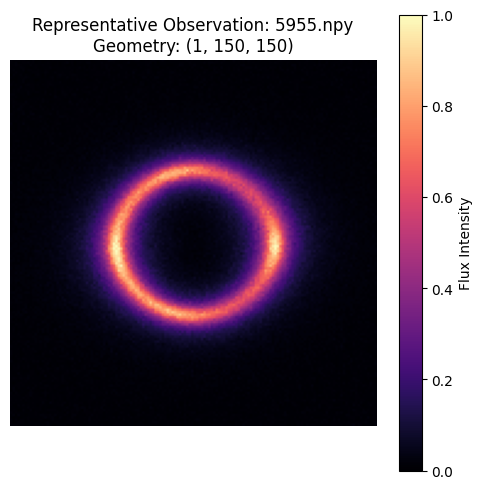

In [91]:
# Exploratory Data Analysis (EDA) & Verification 
# Define search pattern using the primary dataset directory
data_pattern = os.path.join("/kaggle/input/datasets/vanshdistsys2/common-task-dataset/dataset/train/no/*.npy")
sample_files = glob.glob(data_pattern)

if sample_files:
    # Extract a representative sample for dimensionality and flux verification
    sample_path = sample_files[0]
    sample_array = np.load(sample_path)
    
    logging.info(f"Data ingestion successful: {os.path.basename(sample_path)}")
    logging.info(f"Tensor Dimensionality: {sample_array.shape} | Precision: {sample_array.dtype}")
    logging.info(f"Radiometric Flux Range: [{sample_array.min():.4f}, {sample_array.max():.4f}]")
    
    # Visual validation of astrophysical signal
    plt.figure(figsize=(5, 5))
    # Standardizing array for 2D visualization
    render_target = np.squeeze(sample_array) if sample_array.ndim > 2 else sample_array
    
    plt.imshow(render_target, cmap='magma')
    plt.colorbar(label='Flux Intensity')
    plt.title(f"Representative Observation: {os.path.basename(sample_path)}\nGeometry: {sample_array.shape}")
    plt.axis('off')
    plt.tight_layout()
    plt.show()
else:
    logging.error(f"Integrity Check Failed: No .npy files discovered in {data_pattern}")

In [92]:
# Global Hyperparameter Configuration
CONFIG = {
    "seed": 42,
    "epochs": 100,              # Maximum training iterations (Early Stopping controlled)
    "learning_rate": 1e-4, 
    "weight_decay": 1e-4,       # L2 Regularization coefficient
    "batch_size": 32,
    "patience": 7,              # Early stopping epoch threshold
    "device": torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    "classes": ["no", "sphere", "vort"],
    
    # Dataset Directory Mapping
    "train_dir": "/kaggle/input/datasets/vanshdistsys2/common-task-dataset/dataset/train",
    "val_dir": "/kaggle/input/datasets/vanshdistsys2/common-task-dataset/dataset/val"
}

logging.info(f"Execution Device: {CONFIG['device']}")

INFO: Execution Device: cuda


In [93]:
class DeepLenseDataset(Dataset):
    """
    Physically-constrained Dataset for parsing simulated lensing flux arrays.
    Implements stochastic spatial augmentations to enforce rotational invariance.
    """
    def __init__(self, file_paths: List[str], labels: List[int], is_train: bool = False):
        self.file_paths = file_paths
        self.labels = labels
        self.is_train = is_train

    def __len__(self) -> int:
        return len(self.file_paths)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        # Load radiometric flux array [Expected input: (1, H, W)]
        img_array = np.load(self.file_paths[idx]).astype(np.float32)

        # Remove channel dimension for NumPy-based geometric transformations
        img_array = np.squeeze(img_array)

        # Stochastic Spatial Augmentation (Inference-safe)
        if self.is_train:
            # Random Horizontal/Vertical Flips
            if random.random() > 0.5:
                img_array = np.fliplr(img_array).copy()
            if random.random() > 0.5:
                img_array = np.flipud(img_array).copy()
            
            # Discrete 90-degree rotations to maintain pixel-grid alignment
            k = random.randint(0, 3)
            img_array = np.rot90(img_array, k=k).copy()

        # Restore channel dimension for PyTorch compatibility [1, H, W]
        img_array = np.expand_dims(img_array, axis=0)

        return torch.from_numpy(img_array), torch.tensor(self.labels[idx], dtype=torch.long)


def load_paths_and_labels(base_dir: str, classes: List[str]) -> Tuple[List[str], List[int]]:
    """Recursively crawls directory tree to map .npy file paths to class indices."""
    paths, labels = [], []
    for idx, cls_name in enumerate(classes):
        cls_dir = os.path.join(base_dir, cls_name)
        files = glob.glob(os.path.join(cls_dir, "*.npy"))
        paths.extend(files)
        labels.extend([idx] * len(files))
    return paths, labels


def prepare_dataloaders(config: Dict) -> Tuple[DataLoader, DataLoader]:
    """Initializes high-concurrency DataLoaders for train and validation splits."""
    train_paths, train_labels = load_paths_and_labels(config["train_dir"], config["classes"])
    val_paths, val_labels = load_paths_and_labels(config["val_dir"], config["classes"])

    if not train_paths or not val_paths:
        logging.error("Data pipeline failure: Verification of input directories failed.")
        return None, None

    train_set = DeepLenseDataset(train_paths, train_labels, is_train=True)
    val_set = DeepLenseDataset(val_paths, val_labels, is_train=False)

    train_loader = DataLoader(
        train_set, 
        batch_size=config["batch_size"], 
        shuffle=True,
        num_workers=2  # Utilizing multi-core loading for efficiency
    )
    val_loader = DataLoader(
        val_set, 
        batch_size=config["batch_size"], 
        shuffle=False
    )

    logging.info(f"Dataset Pipeline Initialized: {len(train_paths)} training, {len(val_paths)} validation samples.")
    return train_loader, val_loader

# Global Data Initialization
train_loader, val_loader = prepare_dataloaders(CONFIG)

INFO: Dataset Pipeline Initialized: 30000 training, 7500 validation samples.


In [94]:
class CustomPhysicsCNN(nn.Module):
    """
    Architectural Baseline: Shallow Convolutional Neural Network 
    tailored for hierarchical feature extraction from lensing simulations.
    
    Design incorporates Batch Normalization and Dropout (0.5) to mitigate
    overfitting and accelerate convergence on low-SNR astrophysical signals.
    """
    def __init__(self, num_classes: int = 3, input_channels: int = 1):
        super(CustomPhysicsCNN, self).__init__()
        
        # Feature Extraction Backbone
        self.features = nn.Sequential(
            # Block 1: Initial Edge Detection
            nn.Conv2d(input_channels, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),  
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            # Block 2: Intermediate Curvature Learning
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),  
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            # Block 3: High-level Structural Recognition
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), 
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        # Heuristic determination of flattened linear layer dimensions
        with torch.no_grad():
            dummy_input = torch.zeros(1, input_channels, 150, 150) 
            flatten_size = self.features(dummy_input).numel()

        # Classification Head with Regularization
        self.classifier = nn.Sequential(
            nn.Linear(flatten_size, 128),
            nn.BatchNorm1d(128), 
            nn.ReLU(),
            nn.Dropout(0.5), 
            nn.Linear(128, num_classes)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Propagates input through feature backbone and classification head."""
        x = self.features(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

In [95]:
import torchvision.models as models

def get_resnet18(num_classes: int = 3) -> nn.Module:
    """
    Standard ResNet-18 adapted for astrophysical domain-specific constraints.
    
    Modifications:
    1. Input layer reconfigured for single-channel (grayscale) flux maps.
    2. Classification head augmented with Dropout (0.5) to prevent 
       over-parameterized memorization of simulation artifacts.
    """
    # Initialize without pre-trained weights to learn physics-specific kernels
    model = models.resnet18(weights=None) 
    
    # Adaptation of the initial convolutional stem for 1-channel input
    model.conv1 = nn.Conv2d(
        in_channels=1, 
        out_channels=64, 
        kernel_size=7, 
        stride=2, 
        padding=3, 
        bias=False
    )
    
    # Reconfiguration of the Fully Connected (FC) head for multi-class classification
    num_ftrs = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=0.5),
        nn.Linear(num_ftrs, num_classes)
    )
    
    return model

In [96]:
def train_model(model, train_loader, val_loader, config, model_name):
    """
    Core training pipeline with automated convergence monitoring.
    Implements ReduceLROnPlateau scheduling and state-dict checkpointing.
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        model.parameters(), 
        lr=config["learning_rate"], 
        weight_decay=config.get("weight_decay", 1e-4)
    )
    # Scheduler adjusts learning rate based on validation loss stagnation
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)
    
    model.to(config["device"])
    
    # Convergence Monitoring Parameters
    patience = config.get("patience", 7)
    trigger_times = 0
    best_val_loss = float('inf')
    save_path = f'best_{model_name}.pth'
    
    for epoch in range(config["epochs"]):
        # Phase 1: Training
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(config["device"]), labels.to(config["device"])
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

        # Phase 2: Validation (Inference)
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(config["device"]), labels.to(config["device"])
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        # Metric Normalization
        train_loss /= len(train_loader.dataset)
        val_loss /= len(val_loader.dataset)
        train_acc = 100. * train_correct / train_total
        val_acc = 100. * val_correct / val_total
        
        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']

        logging.info(f"[{model_name}] Ep {epoch+1:02d} | Loss (T/V): {train_loss:.4f}/{val_loss:.4f} | Acc (T/V): {train_acc:.2f}%/{val_acc:.2f}% | LR: {current_lr:.6f}")

        # State-Dict Checkpointing & Early Stopping Logic
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            trigger_times = 0
            torch.save(model.state_dict(), save_path)
            logging.info(f"   --> Validation improvement. Optimized weights cached to {save_path}")
        else:
            trigger_times += 1
            if trigger_times >= patience:
                logging.info(f"Convergence threshold reached. Terminating at epoch {epoch+1}.")
                break

    # Restore global minimum state for final evaluation
    model.load_state_dict(torch.load(save_path))
    return model

In [97]:
#Custom CNN Execution
logging.info("Initializing phase: Custom CNN pipeline")
custom_cnn = CustomPhysicsCNN(num_classes=3, input_channels=1)


custom_cnn = train_model(custom_cnn, train_loader, val_loader, CONFIG, "Custom_CNN")

# ResNet-18 Execution
logging.info("Initializing phase: ResNet-18 baseline pipeline")
resnet_model = get_resnet18(num_classes=3)


resnet_model = train_model(resnet_model, train_loader, val_loader, CONFIG, "ResNet18")

INFO: Initializing phase: Custom CNN pipeline
INFO: [Custom_CNN] Ep 01 | Loss (T/V): 1.1441/1.1002 | Acc (T/V): 34.34%/34.65% | LR: 0.000100
INFO:    --> Validation improvement. Optimized weights cached to best_Custom_CNN.pth
INFO: [Custom_CNN] Ep 02 | Loss (T/V): 1.1184/1.0939 | Acc (T/V): 34.81%/36.16% | LR: 0.000100
INFO:    --> Validation improvement. Optimized weights cached to best_Custom_CNN.pth
INFO: [Custom_CNN] Ep 03 | Loss (T/V): 1.1038/1.0892 | Acc (T/V): 36.40%/37.61% | LR: 0.000100
INFO:    --> Validation improvement. Optimized weights cached to best_Custom_CNN.pth
INFO: [Custom_CNN] Ep 04 | Loss (T/V): 1.0909/1.0805 | Acc (T/V): 38.71%/37.31% | LR: 0.000100
INFO:    --> Validation improvement. Optimized weights cached to best_Custom_CNN.pth
INFO: [Custom_CNN] Ep 05 | Loss (T/V): 1.0580/1.0416 | Acc (T/V): 42.66%/43.64% | LR: 0.000100
INFO:    --> Validation improvement. Optimized weights cached to best_Custom_CNN.pth
INFO: [Custom_CNN] Ep 06 | Loss (T/V): 1.0030/0.9955 |

In [101]:
def get_predictions(model, loader, device):
    model.eval()
    all_probs = []
    all_labels = []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            # Use Softmax to get probabilities for the ROC curve
            probs = torch.softmax(outputs, dim=1)
            all_probs.append(probs.cpu().numpy())
            all_labels.append(labels.cpu().numpy())
    return np.concatenate(all_labels), np.concatenate(all_probs)

# Collect data for the plots
labels_val, probs_custom = get_predictions(custom_cnn, val_loader, CONFIG["device"])
_, probs_resnet = get_predictions(resnet_model, val_loader, CONFIG["device"])

In [104]:
def plot_comparative_roc(y_true: np.ndarray, probs_dict: Dict[str, np.ndarray]) -> None:
    """
    Computes and visualizes the Macro-average Receiver Operating Characteristic (ROC) 
    curves to evaluate the discriminative performance of the candidate architectures.
    """
    # Setting a clean, publication-standard style
    plt.style.use('seaborn-v0_8-muted')
    plt.figure(figsize=(9, 7))
    
    # One-vs-Rest (OvR) binarization for multi-class metrics
    y_bin = label_binarize(y_true, classes=[0, 1, 2])
    n_classes = y_bin.shape[1]
    
    # Publication-quality color mapping
    colors = {'Custom_CNN': '#2c7fb8', 'ResNet18': '#d95f02'}
    linestyles = {'Custom_CNN': '-', 'ResNet18': '--'}
    
    for model_name, probs in probs_dict.items():
        fpr, tpr = {}, {}
        for i in range(n_classes):
            fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], probs[:, i])
            
        # Compute Macro-average ROC curve
        all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
        mean_tpr = np.zeros_like(all_fpr)
        for i in range(n_classes):
            mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
            
        mean_tpr /= n_classes
        macro_auc = auc(all_fpr, mean_tpr)
        
        plt.plot(all_fpr, mean_tpr, 
                 label=f'{model_name} (Macro-AUC: {macro_auc:.3f})',
                 color=colors.get(model_name, 'black'), 
                 linestyle=linestyles.get(model_name, '-'), 
                 linewidth=2.2)

    # Reference baseline (Random Chance)
    plt.plot([0, 1], [0, 1], color='gray', linestyle=':', lw=1.2)
    
    # Axes and Labeling
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (FPR)', fontsize=12)
    plt.ylabel('True Positive Rate (TPR)', fontsize=12)
    plt.title('Performance Benchmark: Architectural ROC Comparison', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right", frameon=True)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# ---

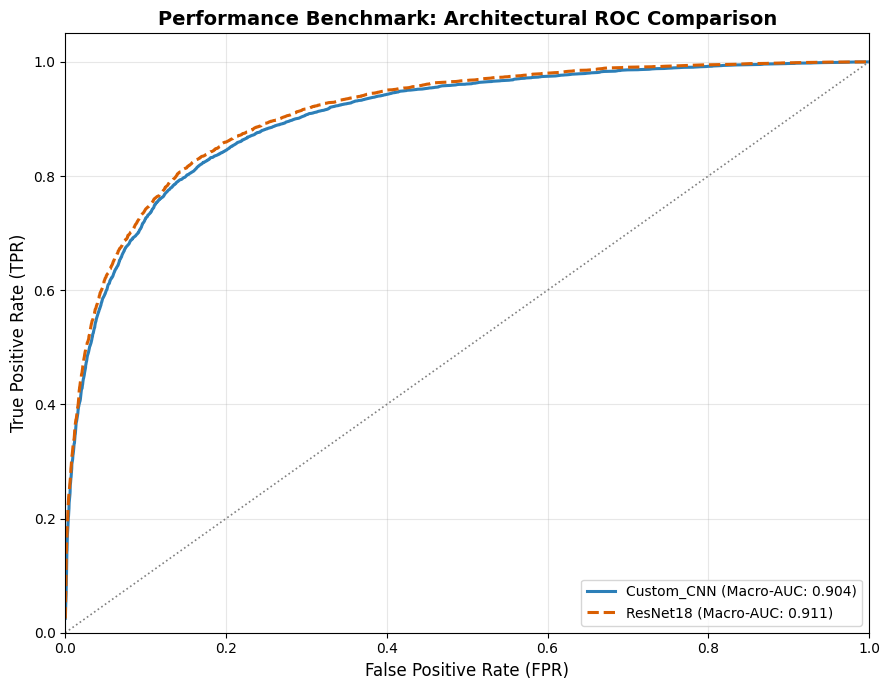

In [103]:
plot_comparative_roc(labels_val, {
    'Custom_CNN': probs_custom,
    'ResNet18': probs_resnet
})